import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_cleaned/superstore_clean.csv", sep=";", encoding="latin1")
df.head()

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'order_date', 'ship_date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'sales', 'Quantity', 'discount', 'profit'],
      dtype='object')

## Sales by Region

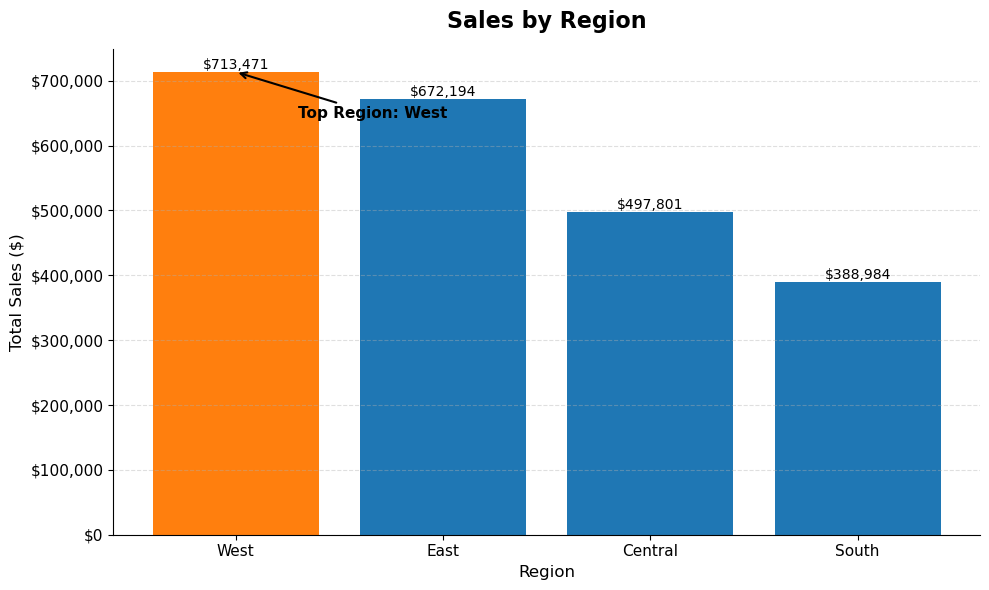

In [12]:
from matplotlib.ticker import FuncFormatter

region_sales = df.groupby("Region")["sales"].sum().sort_values(ascending=False)

# Highlight top region
colors = ["#ff7f0e" if i == 0 else "#1f77b4" for i in range(len(region_sales))]

plt.figure(figsize=(10, 6))
bars = plt.bar(region_sales.index, region_sales.values, color=colors)

plt.title("Sales by Region", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Clean look
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

#  Annotate top region
top_region = region_sales.index[0]
top_value = region_sales.iloc[0]

plt.annotate(
    f"Top Region: {top_region}",
    xy=(0, top_value),
    xytext=(0.3, top_value * 0.9),
    textcoords="data",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

plt.tight_layout()
plt.savefig("visuals/01_sales_by_region.png")
plt.show()

### Insight
The West region generates the highest total sales, confirming its position as the primary revenue driver. The South region contributes the least, indicating a potential opportunity for focused market expansion and performance improvement.

## 2. Profit by Category

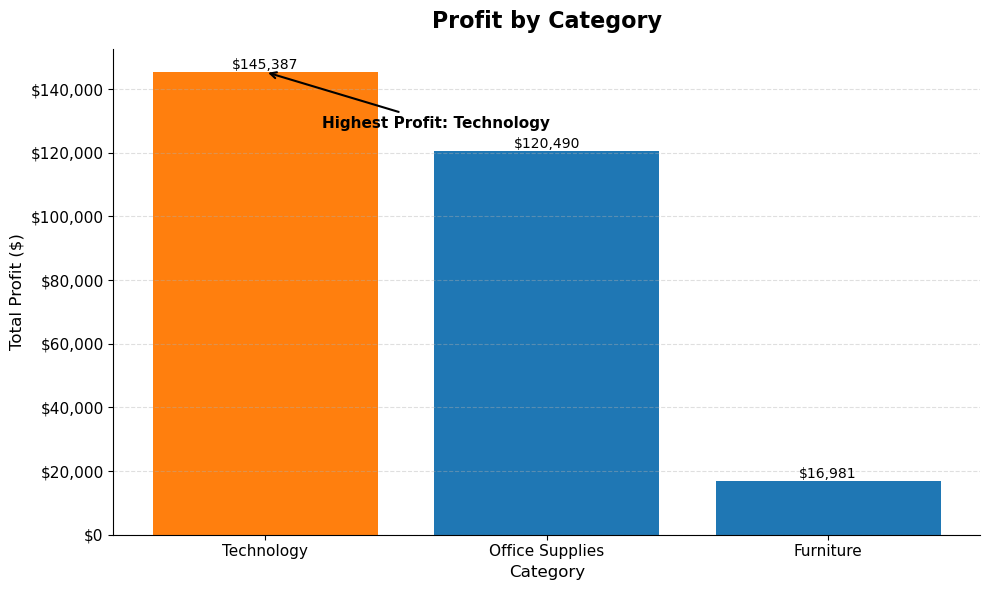

In [13]:
from matplotlib.ticker import FuncFormatter

category_profit = df.groupby("Category")["profit"].sum().sort_values(ascending=False)

colors = ["#ff7f0e" if i == 0 else "#1f77b4" for i in range(len(category_profit))]

plt.figure(figsize=(10, 6))
bars = plt.bar(category_profit.index, category_profit.values, color=colors)

plt.title("Profit by Category", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

top_category = category_profit.index[0]
top_value = category_profit.iloc[0]

plt.annotate(
    f"Highest Profit: {top_category}",
    xy=(0, top_value),
    xytext=(0.2, top_value * 0.88),
    textcoords="data",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

plt.tight_layout()
plt.savefig("visuals/02_profit_by_category.png")
plt.show()

### Insight

Technology generates the highest total profit, making it the most valuable product category. In contrast, Furniture delivers significantly lower profitability despite comparable sales levels, indicating margin pressure and potential inefficiencies in pricing or cost management.

## 3. Monthly Sales Trend

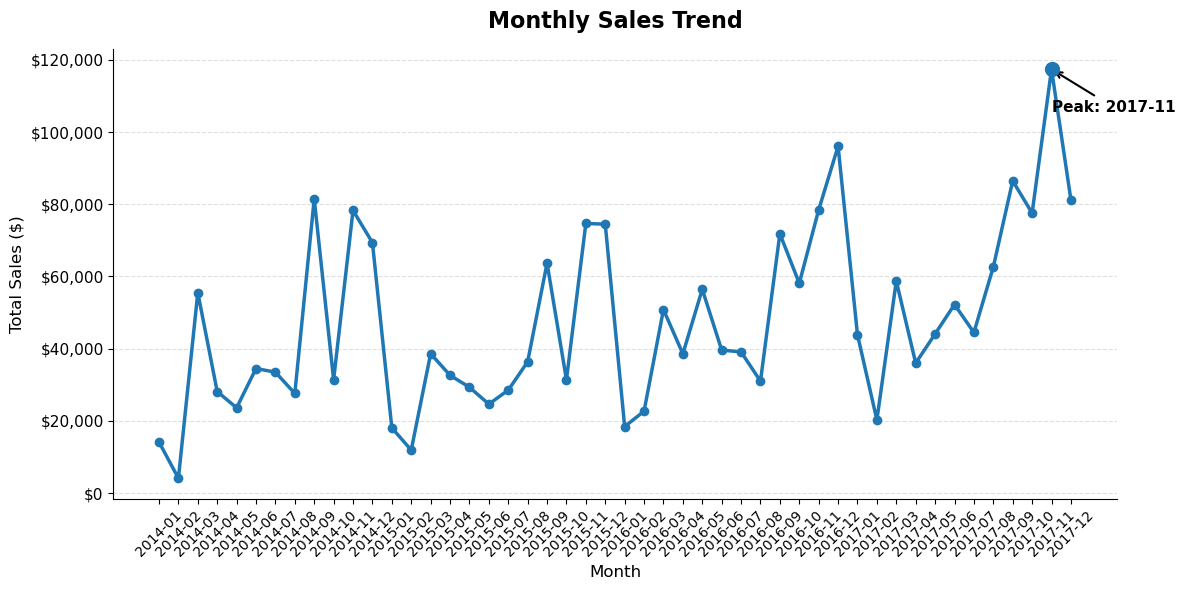

In [14]:
from matplotlib.ticker import FuncFormatter

monthly_sales = (
    df.groupby("order_date")["sales"]
    .sum()
    .reset_index()
)

monthly_sales["order_date"] = pd.to_datetime(monthly_sales["order_date"])
monthly_sales["month"] = monthly_sales["order_date"].dt.to_period("M").astype(str)

monthly_summary = monthly_sales.groupby("month")["sales"].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_summary["month"],
    monthly_summary["sales"],
    marker="o",
    linewidth=2.5
)

plt.title("Monthly Sales Trend", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales ($)", fontsize=12)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=11)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Highlight the peak month
peak_idx = monthly_summary["sales"].idxmax()
peak_month = monthly_summary.loc[peak_idx, "month"]
peak_value = monthly_summary.loc[peak_idx, "sales"]

plt.scatter(peak_month, peak_value, s=100, zorder=5)
plt.annotate(
    f"Peak: {peak_month}",
    xy=(peak_month, peak_value),
    xytext=(peak_idx, peak_value * 0.9),
    textcoords="data",
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

plt.tight_layout()
plt.savefig("visuals/03_monthly_sales_trend.png")
plt.show()

### Insight

Sales fluctuate across months, indicating clear seasonal patterns in business performance. Peak periods suggest strong demand cycles, while lower-performing months highlight opportunities for improved planning, forecasting, and promotional strategy.

## 4. Discount Vs Profit

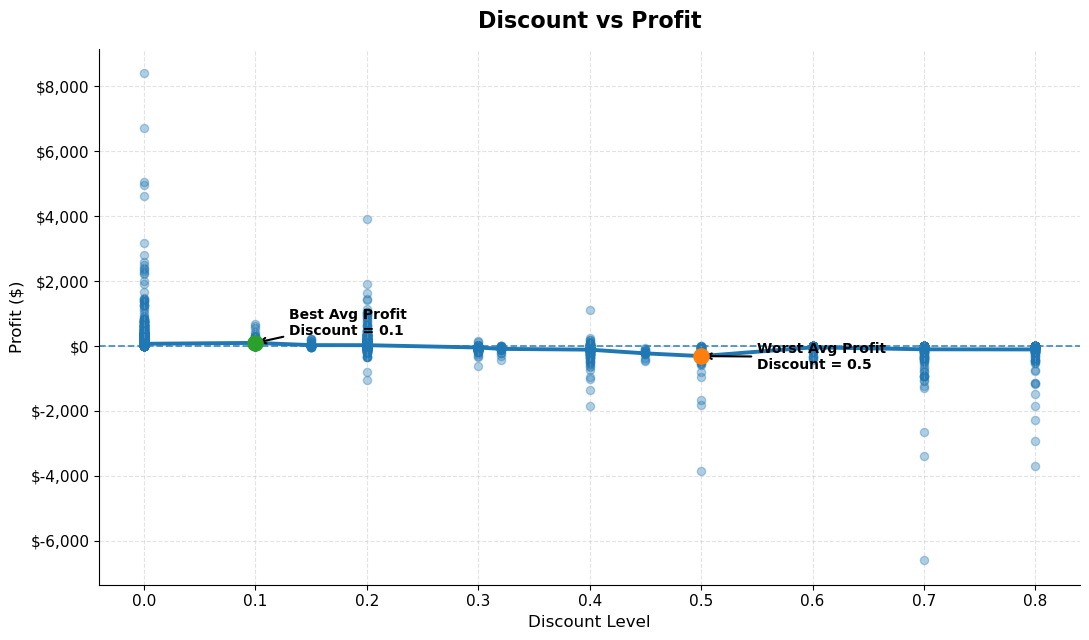

In [15]:
from matplotlib.ticker import FuncFormatter

# Average profit by discount level
discount_profit = (
    df.groupby("discount")["profit"]
    .mean()
    .reset_index()
    .sort_values("discount")
)

plt.figure(figsize=(11, 6.5))

# Scatter plot of all transactions
plt.scatter(
    df["discount"],
    df["profit"],
    alpha=0.35,
    s=35
)

# Zero-profit reference line
plt.axhline(0, linestyle="--", linewidth=1.3, alpha=0.8)

# Average trend line
plt.plot(
    discount_profit["discount"],
    discount_profit["profit"],
    linewidth=2.8,
    marker="o"
)

# Titles and labels
plt.title("Discount vs Profit", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Discount Level", fontsize=12)
plt.ylabel("Profit ($)", fontsize=12)

# Axis formatting
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Clean professional look
plt.grid(True, linestyle="--", alpha=0.35)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Highlight lowest average profit point
lowest_idx = discount_profit["profit"].idxmin()
lowest_discount = discount_profit.loc[lowest_idx, "discount"]
lowest_profit = discount_profit.loc[lowest_idx, "profit"]

plt.scatter(
    [lowest_discount],
    [lowest_profit],
    s=120,
    zorder=5
)

plt.annotate(
    f"Worst Avg Profit\nDiscount = {lowest_discount:.1f}",
    xy=(lowest_discount, lowest_profit),
    xytext=(lowest_discount + 0.05, lowest_profit - 400),
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

# Highlight the best average profit point too
highest_idx = discount_profit["profit"].idxmax()
highest_discount = discount_profit.loc[highest_idx, "discount"]
highest_profit = discount_profit.loc[highest_idx, "profit"]

plt.scatter(
    [highest_discount],
    [highest_profit],
    s=120,
    zorder=5
)

plt.annotate(
    f"Best Avg Profit\nDiscount = {highest_discount:.1f}",
    xy=(highest_discount, highest_profit),
    xytext=(highest_discount + 0.03, highest_profit + 250),
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

plt.tight_layout()
plt.savefig("visuals/04_discount_vs_profit.png")
plt.show()

**Executive takeaway:** Higher discounts do not necessarily translate into stronger profitability and may be damaging margins.

### Insight

Profitability declines as discount levels increase, with higher discount ranges consistently associated with lower average profit and more loss-making transactions. This suggests that aggressive discounting strategies are eroding margins and should be reviewed carefully.

## 5. Customer Segment Performance 

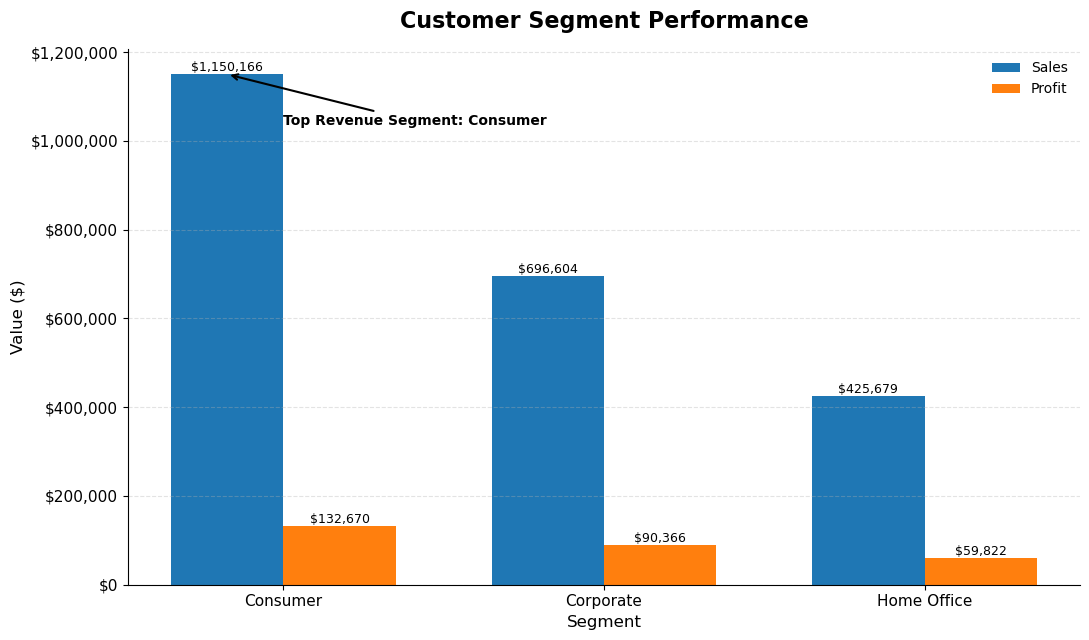

In [16]:
from matplotlib.ticker import FuncFormatter
import numpy as np

segment_summary = (
    df.groupby("Segment")[["sales", "profit"]]
    .sum()
    .sort_values("sales", ascending=False)
)

segments = segment_summary.index
sales_values = segment_summary["sales"].values
profit_values = segment_summary["profit"].values

x = np.arange(len(segments))
width = 0.35

plt.figure(figsize=(11, 6.5))

bars1 = plt.bar(x - width/2, sales_values, width=width, label="Sales")
bars2 = plt.bar(x + width/2, profit_values, width=width, label="Profit")

plt.title("Customer Segment Performance", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Value ($)", fontsize=12)

plt.xticks(x, segments, fontsize=11)
plt.yticks(fontsize=11)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Add labels above bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"${height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Highlight top sales segment
top_segment = segment_summary["sales"].idxmax()
top_idx = list(segments).index(top_segment)
top_value = sales_values[top_idx]

plt.annotate(
    f"Top Revenue Segment: {top_segment}",
    xy=(top_idx - width/2, top_value),
    xytext=(top_idx, top_value * 0.9),
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("visuals/05_customer_segment_performance.png")
plt.show()

**Executive takeaway:** Customer value is concentrated in the Consumer segment, indicating that retention and targeted upselling in this segment could produce the strongest commercial impact.

### Insight

The Consumer segment contributes the highest sales and profit, making it the most valuable customer group. The Corporate segment also performs strongly, while the Home Office segment delivers the lowest overall contribution, suggesting an opportunity for targeted growth and engagement strategies.

## 6. Top Products By Sales 

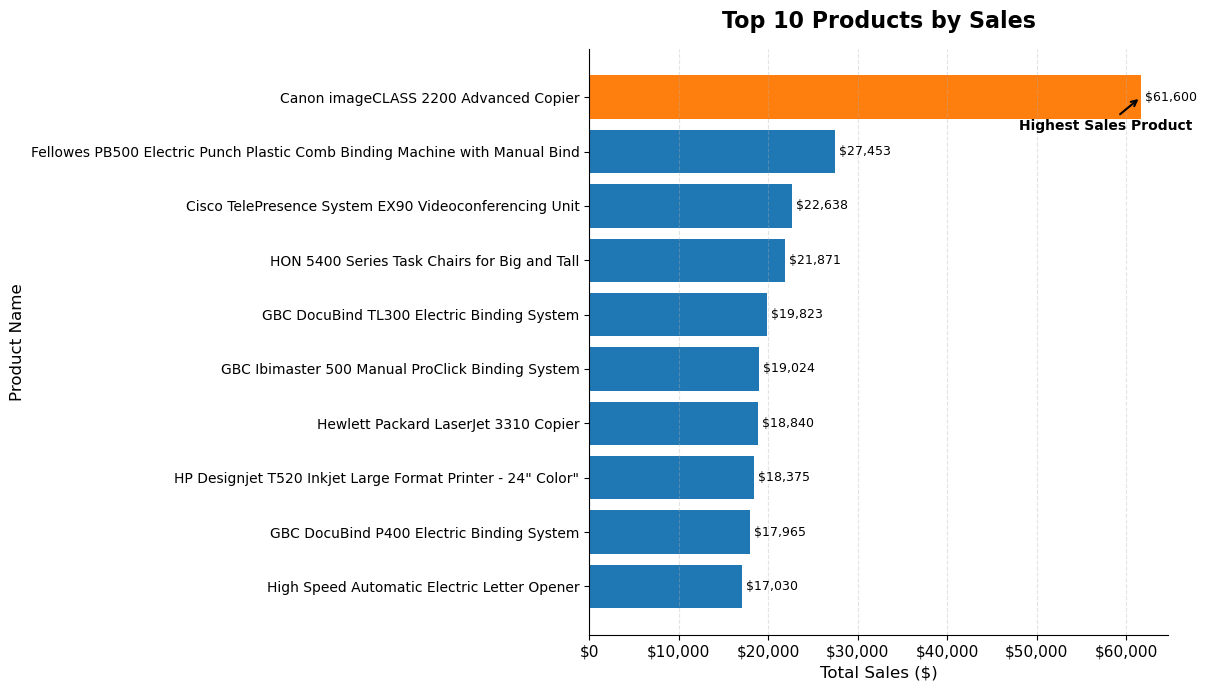

In [17]:
from matplotlib.ticker import FuncFormatter

top_products = (
    df.groupby("Product Name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

colors = ["#1f77b4"] * len(top_products)
colors[-1] = "#ff7f0e"  # highlight top product

plt.figure(figsize=(12, 7))
bars = plt.barh(top_products.index, top_products.values, color=colors)

plt.title("Top 10 Products by Sales", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Total Sales ($)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Add value labels at the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" ${width:,.0f}",
        va="center",
        fontsize=9
    )

# Highlight the top product with annotation
top_product_name = top_products.index[-1]
top_product_value = top_products.iloc[-1]

plt.annotate(
    "Highest Sales Product",
    xy=(top_product_value, len(top_products) - 1),
    xytext=(top_product_value * 0.78, len(top_products) - 1.6),
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

plt.tight_layout()
plt.savefig("visuals/06_top_products_by_sales.png")
plt.show()

**Executive takeaway:** Revenue concentration among a small set of products suggests that protecting availability and optimizing margin on these items could have a significant business impact.

### Insight

A small number of products account for a disproportionately large share of total sales, with the top-performing product emerging as a clear revenue leader. This suggests that product performance is concentrated among a limited set of high-value items, creating opportunities for targeted inventory, promotion, and pricing strategies.

## 7. Low-Profit Products 

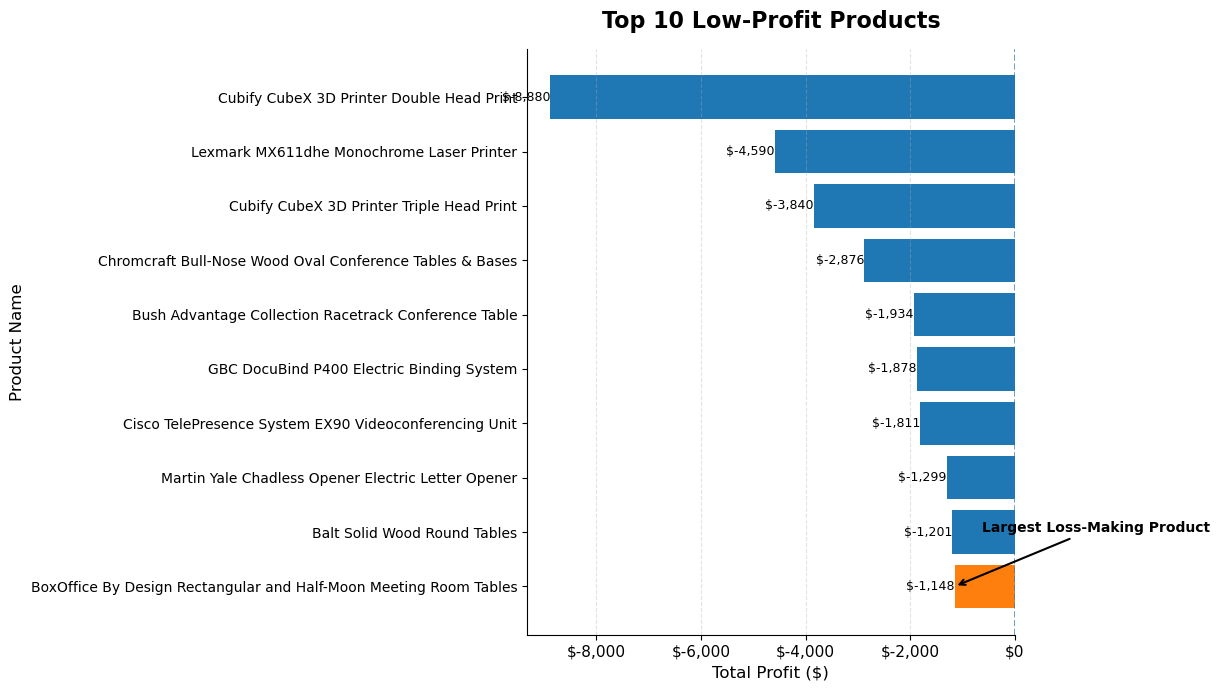

In [20]:
from matplotlib.ticker import FuncFormatter

low_profit_products = (
    df.groupby("Product Name")["profit"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
    .sort_values(ascending=False)
)

colors = ["#1f77b4"] * len(low_profit_products)
colors[0] = "#ff7f0e"  # highlight worst-performing product

plt.figure(figsize=(12, 7))
bars = plt.barh(low_profit_products.index, low_profit_products.values, color=colors)

plt.title("Top 10 Low-Profit Products", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Total Profit ($)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Add zero line for clear reference
plt.axvline(0, linestyle="--", linewidth=1.2, alpha=0.8)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" ${width:,.0f}",
        va="center",
        ha="right" if width < 0 else "left",
        fontsize=9
    )

# Highlight worst-performing product
worst_product_name = low_profit_products.index[0]
worst_product_value = low_profit_products.iloc[0]

plt.annotate(
    "Largest Loss-Making Product",
    xy=(worst_product_value, 0),
    xytext=(worst_product_value * 0.55, 1),
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

plt.tight_layout()
plt.savefig("visuals/07_low_profit_products.png")
plt.show()

**Executive takeaway:** Persistent loss-making products may be eroding the gains generated by top-performing items, making margin-focused product review an important strategic priority.

### Insight
Several products generate substantial losses despite remaining part of the active product portfolio. This indicates that not all products contribute positively to profitability and suggests the need for closer review of pricing, discounting, and cost structures for underperforming items

## 8. Sub-Category Profitability 

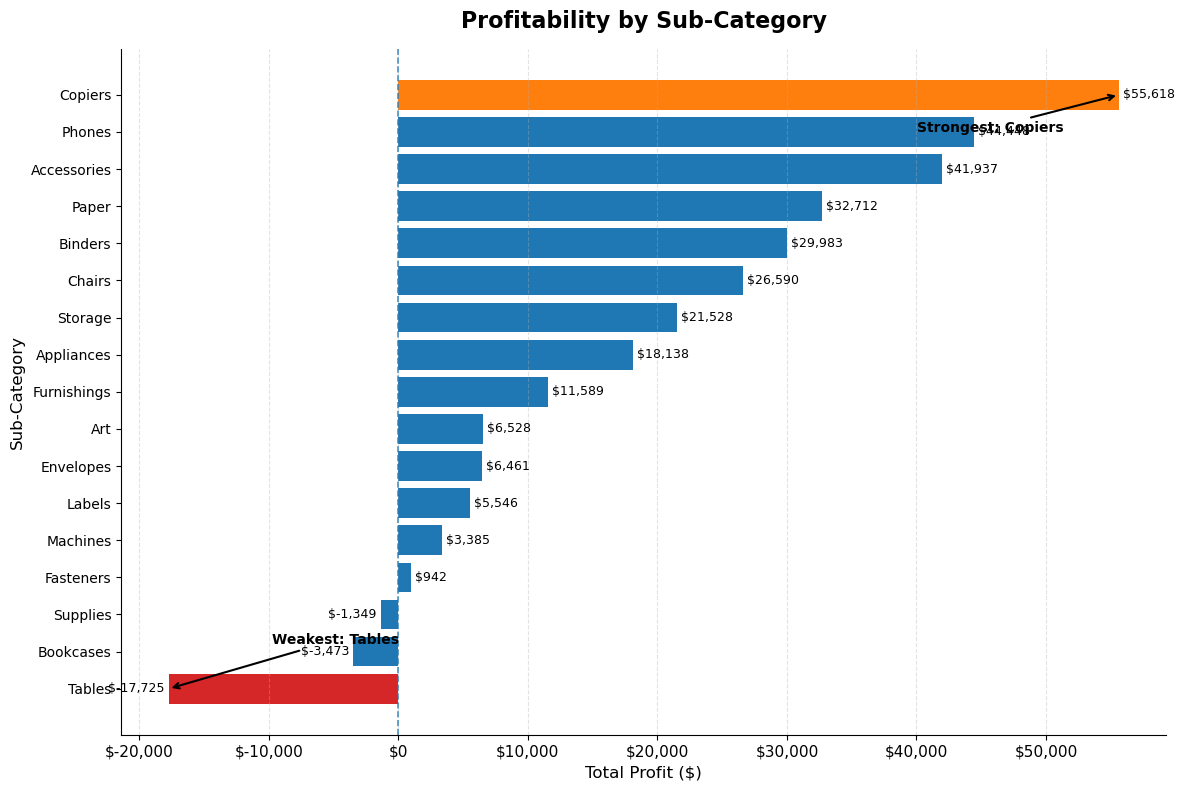

In [21]:
from matplotlib.ticker import FuncFormatter

subcategory_profit = (
    df.groupby("Sub-Category")["profit"]
    .sum()
    .sort_values(ascending=True)
)

# Build colors: highlight best and worst
colors = ["#1f77b4"] * len(subcategory_profit)
colors[0] = "#d62728"   # weakest / loss-making
colors[-1] = "#ff7f0e"  # strongest / most profitable

plt.figure(figsize=(12, 8))
bars = plt.barh(subcategory_profit.index, subcategory_profit.values, color=colors)

plt.title("Profitability by Sub-Category", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Total Profit ($)", fontsize=12)
plt.ylabel("Sub-Category", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Zero-profit reference line
plt.axvline(0, linestyle="--", linewidth=1.2, alpha=0.8)

# Add labels to bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    if width >= 0:
        plt.text(width, y, f" ${width:,.0f}", va="center", ha="left", fontsize=9)
    else:
        plt.text(width, y, f"${width:,.0f} ", va="center", ha="right", fontsize=9)

# Highlight weakest sub-category
weakest_name = subcategory_profit.index[0]
weakest_value = subcategory_profit.iloc[0]

plt.annotate(
    f"Weakest: {weakest_name}",
    xy=(weakest_value, 0),
    xytext=(weakest_value * 0.55, 1.2),
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

# Highlight strongest sub-category
strongest_name = subcategory_profit.index[-1]
strongest_value = subcategory_profit.iloc[-1]

plt.annotate(
    f"Strongest: {strongest_name}",
    xy=(strongest_value, len(subcategory_profit) - 1),
    xytext=(strongest_value * 0.72, len(subcategory_profit) - 2),
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.5)
)

plt.tight_layout()
plt.savefig("visuals/08_subcategory_profitability.png")
plt.show()

**Executive takeaway:** Sub-category analysis reveals where profitability is concentrated and where corrective action is needed, making it a valuable tool for pricing, assortment, and margin optimization decisions.

### Insight

Profitability varies significantly across sub-categories, with some generating strong returns while others operate at very low or negative margins. This indicates that performance is not evenly distributed within broader product categories and that margin improvement efforts should be targeted at the weakest sub-categories.